# Two steps Neural Networks

In [1]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
#from ann_functions3D_noise_fourier import getModel, kCrossVal, transfBestparam, import_data, normalization
#from Multifidelity_support import getModel, kCrossVal, transfBestparam, import_data, normalization, add_noise, MultiFidelity

from time import perf_counter
import pandas
import pickle
import os
from itertools import product
import keras
import tensorflow as tf

from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)

In [2]:
# reproducibility
seed=42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

## Data preparation

In [3]:
Discretizations= np.loadtxt(
    "../DATA_reaction/Discretizations.txt"
).astype(
    int
)[::-1]

diffusion= np.loadtxt(
    "../DATA_reaction/diffusion.txt"
).astype(
    int
)

In [4]:
########################     PREPARATION      ##########################
# introduction of the data
file_path_HF = "../DATA_reaction/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test, x_HF_test) = import_data(file_path_HF)
U_HF_test = U_HF_test[:, -1, :,44]


reaction_HF_test = normalization(reaction_HF_test)
x_HF_test = normalization(x_HF_test)
U_HF_test = normalization(U_HF_test)

reaction_HF_test_original=reaction_HF_test
x_HF_test_original=x_HF_test
U_HF_test_original=U_HF_test

In [7]:
#########################     TRAIN SET      ##########################
Nepo = [2000,2000]  # number of epochs for second NN: NN_HF
batch_size=[150,80]

Nlf=np.array([150])
n_HF=np.array([80])

In [9]:
noise_stddev2 = [0.01,0.005,0.02,0.005]      
noise_stddev1 = [0.005,0.003,0.01,0.003]  

(U_HF_test,reaction_HF_test)=add_noise(noise_stddev1,noise_stddev2,reaction_HF_test,U_HF_test)

In [10]:
noise_stddev2 = [0.0001,  0.00005, 0.0002, 0.00005]# value?
noise_stddev1=[0.0025, 0.0015, 0.005, 0.0015  ]

(U_HF_test,x_HF_test)=add_noise(noise_stddev1,noise_stddev2,x_HF_test,U_HF_test)



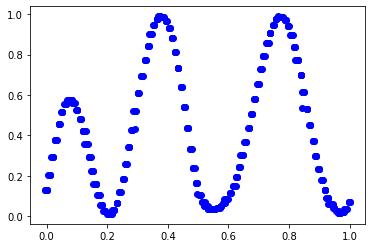

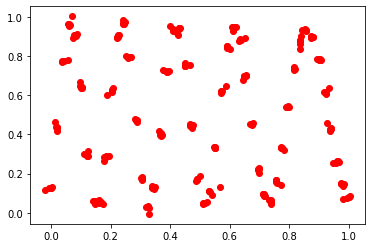

In [11]:
plt.plot(x_HF_test, U_HF_test[0,:], "bo", linewidth=1, label="HF model")
plt.show()

plt.plot(reaction_HF_test, U_HF_test[:,0], "ro", linewidth=1, label="HF model")
plt.show()


In [12]:
reaction_HF_test_original=np.array(list(product(reaction_HF_test_original.flatten(), x_HF_test_original.flatten())))


permutation1 = np.random.permutation(len(reaction_HF_test))
permutation2 = np.random.permutation(len(x_HF_test))

reaction_HF = reaction_HF_test[permutation1][0:n_HF]
x_HF = x_HF_test[permutation2][0:n_HF]

grid1, grid2 = np.meshgrid(reaction_HF, x_HF)
reaction_HF = np.column_stack((grid1.ravel(), grid2.ravel()))
reaction_HF_test = np.array(list(product(reaction_HF_test.flatten(), x_HF_test.flatten())))

reaction_HF_test_original=np.c_[reaction_HF_test_original,np.abs(np.sin(5*np.pi*reaction_HF_test_original[:, 0])) ,np.abs(np.sin(3.5*np.pi*reaction_HF_test_original[:, 1])),np.ones(reaction_HF_test_original.shape[0])]
reaction_HF=np.c_[reaction_HF, np.abs(np.sin(5*np.pi*reaction_HF[:, 0])),np.abs(np.sin(3.5*np.pi*reaction_HF[:, 1])),np.ones(reaction_HF.shape[0])]
reaction_HF_test=np.c_[reaction_HF_test,np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0])) ,np.abs(np.sin(3.5*np.pi*reaction_HF_test[:, 1])),np.ones(reaction_HF_test.shape[0])]


p1, p2 = np.meshgrid(permutation1[0:n_HF], permutation2[0:n_HF])
permutation = np.column_stack((p1.ravel(), p2.ravel()))
U_HF = U_HF_test[permutation[:,0],permutation[:,1]] 
row, col = U_HF_test.shape
index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
U_HF_test = U_HF_test.flatten()[comb]

row, col = U_HF_test_original.shape
index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
U_HF_test_original = U_HF_test_original.flatten()[comb]


In [13]:
U_LF_list = []
U_HF_list = []

r2_HF_df = pandas.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores LF R^2
mse_HF_df = pandas.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores LF MSE

(22500, 5)
(57500,)
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 0  ********************


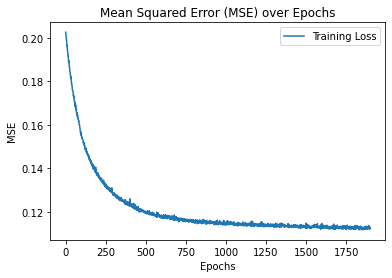

72/72 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.10576317777051593
R^2: 0.15198431879100371
200/200 [==============================] - 0s 2ms/step


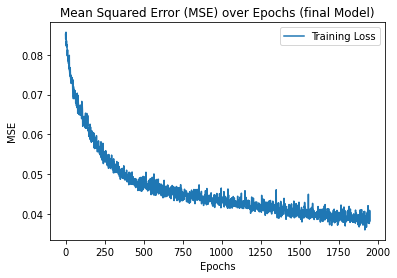

157/157 [==============================] - 0s 2ms/step
Elapsed time:  356.14201550002326

HF Model:
Test MSE: 0.07470401525964046
R^2: 0.33100556633320954
1797/1797 [==============================] - 3s 2ms/step


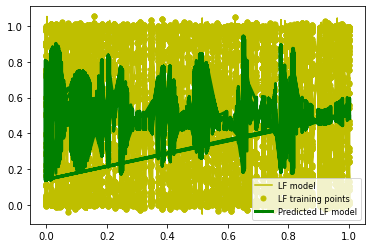

1797/1797 [==============================] - 3s 2ms/step


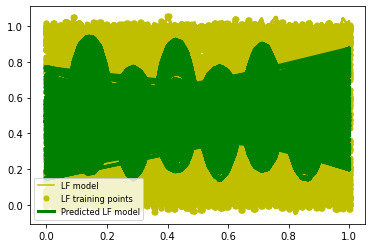

16/16 [==============================] - 0s 2ms/step


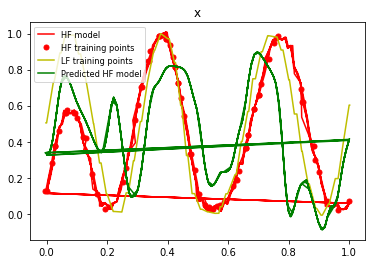

8/8 [==============================] - 0s 2ms/step


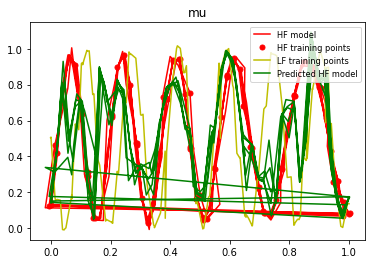

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10772\98253540.py:350: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10772\98253540.py:352: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10772\98253540.py:354: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10772\98253540.py:356: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new, ign

(22500, 5)
(57500,)
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 5  ********************


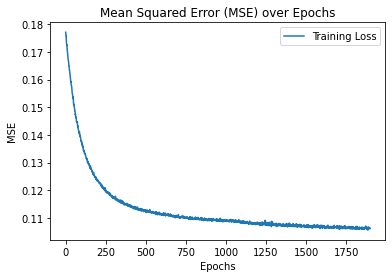

72/72 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.10187040199599709
R^2: 0.07815440359662884
200/200 [==============================] - 0s 2ms/step


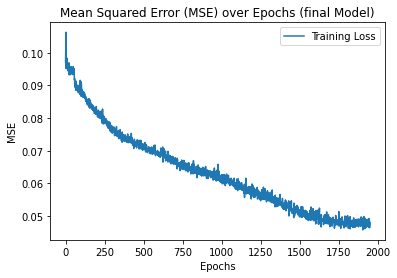

157/157 [==============================] - 0s 2ms/step
Elapsed time:  354.732450600015

HF Model:
Test MSE: 0.08206241997236331
R^2: 0.26510908437879677
1797/1797 [==============================] - 3s 2ms/step


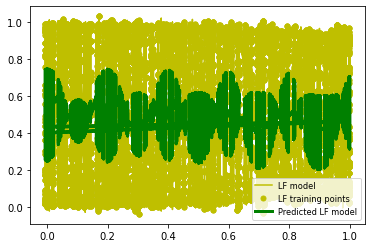

1797/1797 [==============================] - 4s 2ms/step


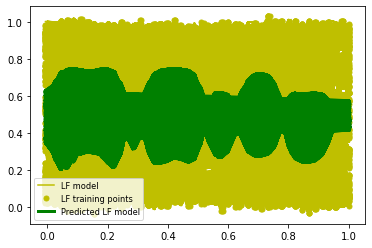

16/16 [==============================] - 0s 3ms/step


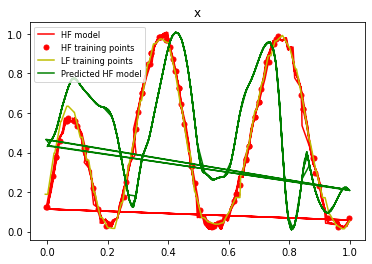

8/8 [==============================] - 0s 2ms/step


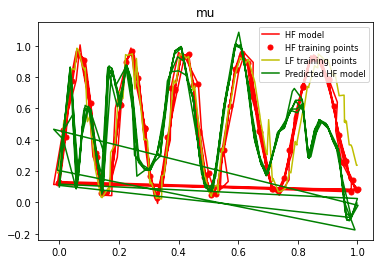

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10772\98253540.py:350: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10772\98253540.py:352: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10772\98253540.py:354: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10772\98253540.py:356: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new, ign

(22500, 5)
(57500,)
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************


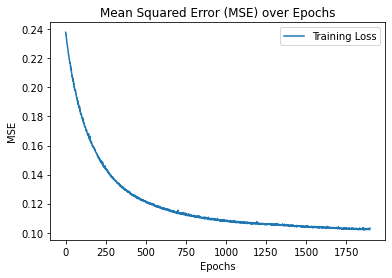

72/72 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.10059338170893832
R^2: 0.0858013048288151
200/200 [==============================] - 1s 2ms/step


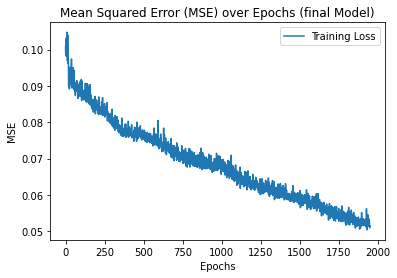

157/157 [==============================] - 0s 2ms/step
Elapsed time:  369.0653866000066

HF Model:
Test MSE: 0.07908900264059394
R^2: 0.2917368317228777
1797/1797 [==============================] - 4s 2ms/step


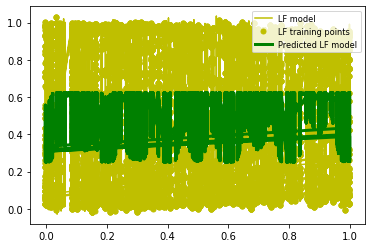

1797/1797 [==============================] - 4s 2ms/step


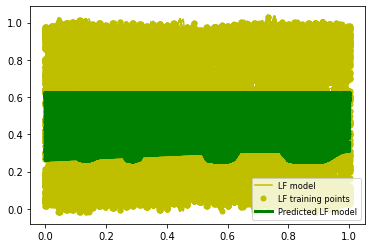

16/16 [==============================] - 0s 3ms/step


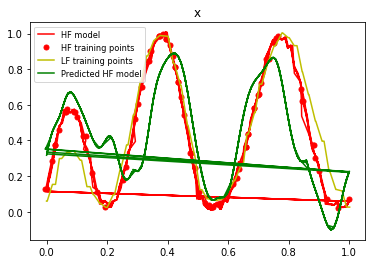

8/8 [==============================] - 0s 2ms/step


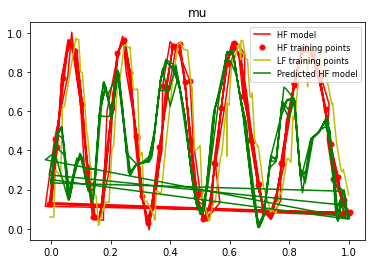

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10772\98253540.py:350: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10772\98253540.py:352: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10772\98253540.py:354: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10772\98253540.py:356: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new, ign

(22500, 5)
(57500,)
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 1  ********************


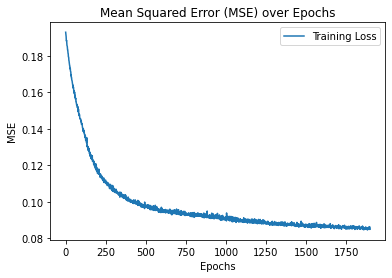

72/72 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 0.06583213298466854
R^2: 0.39775409265017847
200/200 [==============================] - 0s 2ms/step


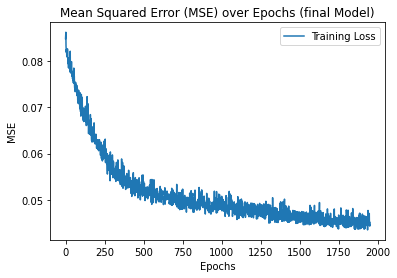

157/157 [==============================] - 0s 3ms/step
Elapsed time:  381.9073739000014

HF Model:
Test MSE: 0.07841372032190183
R^2: 0.29778416546777076
1797/1797 [==============================] - 4s 2ms/step


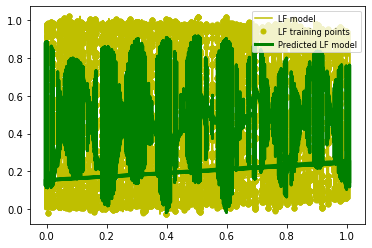

1797/1797 [==============================] - 4s 2ms/step


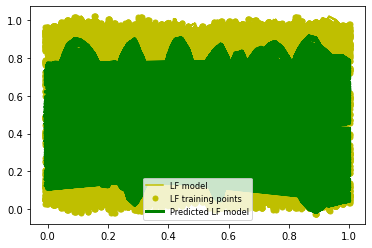

16/16 [==============================] - 0s 2ms/step


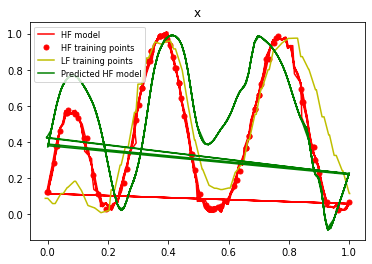

8/8 [==============================] - 0s 2ms/step


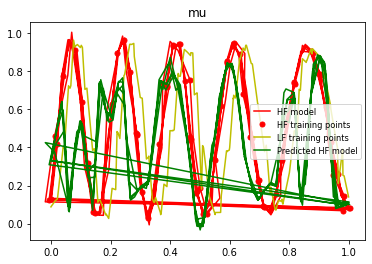

   Discretization  diffusion       R2
0            46.0        0.0  0.33101
1            46.0        5.0  0.26511
2            46.0       75.0  0.29174
3            46.0        1.0  0.29778
   Discretization  diffusion      MSE
0            46.0        0.0  0.07470
1            46.0        5.0  0.08206
2            46.0       75.0  0.07909
3            46.0        1.0  0.07841


C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10772\98253540.py:350: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10772\98253540.py:352: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10772\98253540.py:354: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_10772\98253540.py:356: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new, ign

In [14]:

# Name of the folder
folder_name = "2_step_models"
folder_path = os.path.join(os.getcwd(), folder_name)

# create the folder
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_name}' created.")
else:
    print(f"Folder '{folder_name}' already exists.")
               

for m in range(len(Discretizations)):
    test_mse_HF_list = []
    test_mse_LF_list = []

    r2_HF_list = []
    r2_LF_list = []
    for d in range(len(diffusion)):
        
        print(
        f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
        )
        
        print(
        f"********************  # Diff: = {diffusion[d]}  ********************"
        )
        file_name= "../DATA_reaction/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
        (reaction_LF_test, U_LF_test, x_LF_test) = import_data(file_name)
       
        U_LF_test = U_LF_test[
        :,
        - 1,
        :,
        int(4*(Discretizations[m]-1)/9)
        ]
         
        reaction_LF_test = normalization(reaction_LF_test)
        x_LF_test = normalization(x_LF_test)
        U_LF_test = normalization(U_LF_test)

        reaction_LF_test_original=reaction_LF_test
        x_LF_test_original=x_LF_test
        U_LF_test_original=U_LF_test
        
        noise_std2=[ 0.01 ,0.005 ,0.02,0.005]
        noise_std1=[0.005,0.003,0.01,0.003]
        
        (U_LF_test,reaction_LF_test)=add_noise(noise_std1,noise_std2,reaction_LF_test,U_LF_test)

        noise_std2=[ 0.0001 ,0.00005 ,0.0002,0.00005]
        noise_std1=[0.0025,0.0015,0.005,0.0015]

        (U_LF_test,x_LF_test)=add_noise(noise_std1,noise_std2,x_LF_test,U_LF_test)


        reaction_LF_test_original=np.array(list(product(reaction_LF_test_original.flatten(), x_LF_test_original.flatten())))
        reaction_LF_test_original=np.c_[reaction_LF_test_original,np.abs(np.sin(5*np.pi*reaction_LF_test_original[:, 0])) ,np.abs(np.sin(3.5*np.pi*reaction_LF_test_original[:, 1])),np.ones(reaction_LF_test_original.shape[0])]

        row, col = U_LF_test_original.shape
        index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
        comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
        U_LF_test_original = U_LF_test_original.flatten()[comb]

        L=np.minimum(Nlf,x_LF_test.shape[0])
        permutation1 = np.random.permutation(len(reaction_LF_test))
        permutation2 = np.random.permutation(len(x_LF_test))
        reaction_LF = reaction_LF_test[permutation1][0:Nlf]    # problema di consistenza qui: non stai confrontando stesso numero di dati, ma è cosairreparabile se non creando nuovo dataset
        x_LF = x_LF_test[permutation2][0:L]
        
        grid1, grid2 = np.meshgrid(reaction_LF, x_LF)
        reaction_LF = np.column_stack((grid1.ravel(), grid2.ravel()))
        reaction_LF_test = np.array(list(product(reaction_LF_test.flatten(), x_LF_test.flatten())))
       
        
        reaction_LF=np.c_[reaction_LF, np.abs(np.sin(5*np.pi*reaction_LF[:, 0])),np.abs(np.sin(3.5*np.pi*reaction_LF[:, 1])),np.ones(reaction_LF.shape[0])]
        reaction_LF_test=np.c_[reaction_LF_test,np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0])) ,np.abs(np.sin(3.5*np.pi*reaction_LF_test[:, 1])),np.ones(reaction_LF_test.shape[0])]

      
        p1, p2 = np.meshgrid(permutation1[0:Nlf], permutation2[0:L])
        permutation = np.column_stack((p1.ravel(), p2.ravel()))
        U_train_LF = U_LF_test[permutation[:,0],permutation[:,1]]
        
        row, col = U_LF_test.shape
        index_row, index_col = np.meshgrid(np.arange(row), np.arange(col), indexing='ij')
        comb = np.ravel_multi_index((index_row.flatten(), index_col.flatten()), dims=(row, col))
        U_LF_test = U_LF_test.flatten()[comb]

        
        ##########################       FIRST NN: NN_LF     ##########################
        K.clear_session()
        bestLF_params = {
            "lr": 0.0255,
            "kernel_init": "glorot_uniform",
            "opt": "Adam",
        } 

        best_params = {
            "kernel_init": "uniform",
            "l2weight": 0.0002588943618918075,
            "lr": 0.008365144388542751,
            "nodes": 64.0,
            "opt": "Adam",
        }
        
        names=["LF","HF"]
        params=[bestLF_params, best_params]
        data_train=[reaction_LF, reaction_HF]
        output_train=[U_train_LF,U_HF]
        
        model= NetworkFactory.build_network("2step",names,params=params,data_train=data_train,output_train=output_train,N=Nepo,n=batch_size,do_HPO=False,verbose=False)

# low fidelity part of the network 
        ULF = model.model_list[0].prediction(reaction_LF_test_original)
        print("low fidelity NN")

        (test_mse_LF,r2_LF) = model.model_list[0].performance(reaction_LF_test_original,U_LF_test_original)
        test_mse_LF_list.append(test_mse_LF)
        r2_LF_list.append(r2_LF)


        reaction_test_help =  model.model_list[0].prediction(reaction_HF_test)[:, 0]
        reaction_test_in = np.concatenate(
        (reaction_HF_test, reaction_test_help.reshape(-1,1)),axis=1
        )   # <- TEST INPUT for the second NN: NN_HF

        reaction_test_help_original = model.model_list[0].prediction(reaction_HF_test_original)[:, 0]
        reaction_test_in_original = np.concatenate(
        (reaction_HF_test_original, reaction_test_help_original.reshape(-1,1)),axis=1
        )   # <- TEST INPUT for the second NN: NN_HF



        reaction_train_help = model.model_list[0].prediction(reaction_HF)[
            :, 0
        ]  # f_LF(mu_hf_train)
        reaction_final = np.concatenate(
        (reaction_HF, reaction_train_help.reshape(-1,1)),axis=1
        )  # <- TRAINING INPUT for the second NN: NN_HF

        UHF =  model.model_list[1].prediction(reaction_test_in_original)
        U_HF_list.append(UHF)

        (test_mse_HF,r2_HF) = model.model_list[0].performance(reaction_test_in_original,U_HF_test_original)
        test_mse_HF_list.append(test_mse_HF)
        r2_HF_list.append(r2_HF)
        
        plt.figure()
        plt.plot(
        reaction_LF_test[:, 0], U_LF_test, "y-", linewidth=1.5, label="LF model"
        )
        plt.plot(
        reaction_LF[:, 0],
        U_train_LF,
        "yo",
        markersize=5,
        label="LF training points",
        )
        plt.plot(
        reaction_LF_test[:, 0],
        model.model_list[0].prediction(reaction_LF_test),
        "g-",
        linewidth=3,
        label="Predicted LF model",
        )
        plt.legend(prop={"size": 8.3})
        plt.show()
        
        plt.figure()
        plt.plot(
        reaction_LF_test[:, 1], U_LF_test, "y-", linewidth=1.5, label="LF model"
        )
        plt.plot(
        reaction_LF[:, 1],
        U_train_LF,
        "yo",
        markersize=5,
        label="LF training points",
        )
        plt.plot(
        reaction_LF_test[:, 1],
        model.model_list[0].prediction(reaction_LF_test),
        "g-",
        linewidth=3,
        label="Predicted LF model",
        )
        plt.legend(prop={"size": 8.3})
        plt.show()
        
        
           
        index_order=np.argsort(reaction_test_in[:,0])
        index_order_LF=np.argsort(reaction_LF[:,0])
        
        
        plt.figure()
        mask1_test=np.where(reaction_test_in[:,0]==reaction_test_in[:,0][index_order[2]])
        mask1=np.where(reaction_final[:,0]==np.min(reaction_final[:,0]))
        mask1_LF=np.where(reaction_LF[:,0]==reaction_LF[:,0][index_order_LF[2]])
        order=np.argsort(reaction_LF[mask1_LF,1])
# plt.plot(mu_test, U_hf_test, 'b-', linewidth = 1.5, label = 'HF model')
# plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
        plt.plot(reaction_test_in[mask1_test,1].T, U_HF_test[mask1_test], "r-", linewidth=1.5, label="HF model")
        plt.plot(reaction_final[mask1,1].T, U_HF[mask1], "ro", markersize=5, label="HF training points")
        plt.plot(reaction_LF[mask1_LF,1].T[order[0,:]], U_train_LF[mask1_LF][order[0,:]], "y-", markersize=5, label="LF training points")
        plt.plot(
        reaction_test_in[mask1_test, 1].T,
        model.model_list[1].prediction(reaction_test_in[mask1_test, :][0,:,:]),
        "g-",
        markersize=5,
        label="Predicted HF model",
        )

        plt.legend(prop={"size": 8.3})  
        plt.title("x")
        plt.show()
        
        index_order=np.argsort(reaction_test_in[:,1])
        index_order_LF=np.argsort(reaction_LF[:,1])  

        plt.figure()
        mask2_test=np.where(reaction_test_in[:,1]==reaction_test_in[:,1][index_order[2]])
        mask2=np.where(reaction_final[:,1]==np.min(reaction_final[:,1]))   
        mask2_LF=np.where(reaction_LF[:,1]==reaction_LF[:,1][index_order_LF[2]])
        order=np.argsort(reaction_LF[mask2_LF,0])
# plt.plot(mu_test, U_hf_test, 'b-', linewidth = 1.5, label = 'HF model')
# plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
        plt.plot(reaction_test_in[mask2_test,0].T, U_HF_test[mask2_test], "r-", linewidth=1.5, label="HF model")
        plt.plot(reaction_final[mask2,0].T, U_HF[mask2], "ro", markersize=5, label="HF training points")
        plt.plot(reaction_LF[mask2_LF,0].T[order[0,:]], U_train_LF[mask2_LF][order[0,:]], "y-", markersize=5, label="LF training points")
        plt.plot(
        reaction_test_in[mask2_test, 0].T,
        model.model_list[1].prediction(reaction_test_in[mask2_test, :][0,:,:]),
        "g-",
        markersize=5,
        label="Predicted HF model",
        )

        plt.legend(prop={"size": 8.3})
        plt.title("mu")
        plt.show()

        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
        r2_LF_df=r2_LF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
        r2_HF_df=r2_HF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}
        mse_LF_df=mse_LF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}
        mse_HF_df=mse_HF_df.append(new, ignore_index=True)
        
        # save the model
        if not r2_HF_list[:-1]:
            model.save(str(Discretizations[m]),folder_path)
        elif r2_HF_list[:-1] and r2_HF_list[-1] < max(r2_HF_list[:-1]):
            model.save(str(Discretizations[m]),folder_path)
        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))



## Save the output

In [16]:
os.makedirs("MF_LF_150_2000_HF_80_2000_2NN_multiparam")

r2_HF_df.to_csv(
    "./MF_LF_150_2000_HF_80_2000_2NN_multiparam/r2_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_HF_df.to_csv(
    "./MF_LF_150_2000_HF_80_2000_2NN_multiparam/mse_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
r2_LF_df.to_csv(
    "./MF_LF_150_2000_HF_80_2000_2NN_multiparam/r2_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_LF_df.to_csv(
    "./MF_LF_150_2000_HF_80_2000_2NN_multiparam/mse_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)

with open("./MF_LF_150_2000_HF_80_2000_2NN_multiparam/U_HF_list.data", "wb") as filehandle:
    # store the data as binary data stream
    pickle.dump(U_HF_list, filehandle)

with open("./MF_LF_150_2000_HF_80_2000_2NN_multiparam/U_LF_list.data", "wb") as filehandle:
    pickle.dump(U_LF_list, filehandle)